# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [6]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [8]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [9]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

**- El dataset no tiene valores ausentes.**


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [10]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [11]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [12]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [13]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [20]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [23]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
columnas_categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
print(df[columnas_categoricas].apply(lambda x: x.value_counts()))



Conteo de categorías:
            landing   region  dispositivo  traffic_source  user_type
A           19982.0      NaN          NaN             NaN        NaN
Ads             NaN      NaN          NaN         11935.0        NaN
B           20018.0      NaN          NaN             NaN        NaN
Centro          NaN   9613.0          NaN             NaN        NaN
Desktop         NaN      NaN      15171.0             NaN        NaN
Email           NaN      NaN          NaN          6123.0        NaN
Mobile          NaN      NaN      24829.0             NaN        NaN
Norte           NaN  11166.0          NaN             NaN        NaN
Nuevo           NaN      NaN          NaN             NaN    26033.0
Occidente       NaN   6398.0          NaN             NaN        NaN
Organic         NaN      NaN          NaN         17987.0        NaN
Oriente         NaN   4784.0          NaN             NaN        NaN
Recurrente      NaN      NaN          NaN             NaN    13967.0
Referral   

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

**- Todas las columnas tienen valores esperados.**

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [41]:
# Gasto por versión
gasto_A =  df[(df['landing'] == 'A') & (df['converted'] == 1)] ['gasto']#completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']  #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

In [37]:
df.groupby('landing')['converted'].mean()

landing
A    0.125713
B    0.159556
Name: converted, dtype: float64

In [38]:
df.groupby('landing')['gasto'].describe()

,count,mean,std,min,25%,50%,75%,max
landing,,,,,,,,
A,19982.0,7.679385,22.692226,0.0,0.0,0.0,0.0,303.68
B,20018.0,10.968762,28.233360,0.0,0.0,0.0,0.0,249.99


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [43]:

# Aplicar prueba

t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")

Estadístico t: -9.36563589591332
Valor P: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**rechazamos la hipótesis nula: hay evidencia suficiente de una diferencia.**

**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.

**En lecciones pasadas nos compartieron la regla:**


**Si p < 0.05 → se rechaza la hipótesis nula.**

**Si p ≥ 0.05 → no se rechaza.**

**ya que Valor p: 1.06 × 10⁻²⁰ (es decir, 0.0000000000000000000106) haciendo una conversion el valor de p_value es de 0.0106 nenor que 0.05**

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [46]:
# Número de usuarios convertidos por página

convertidos = df.groupby('landing')['converted'].sum()
convertidos 

# Total de usuarios por página

totales = df.groupby('landing')['converted'].count()
totales

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [48]:
# Aplicar prueba

z_stat, p_value = proportions_ztest(convertidos , totales)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Se rechaza la hipotesisi nula**

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.

**La pagina A y la pagina B no estan convirtiendo usuarios a clientes en la misma cantidad la pagina B convierte mas usuarios a clientes que la pagina A**


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [51]:
#contamos la cantidad total de usuarios que se convirtieron en clientes con value_counts().
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

In [52]:
# Agregamos el traffic_source a nuestra lista de columnas para value_counts().
df[['traffic_source','converted']].value_counts()

traffic_source  converted
Organic         0            15507
Ads             0            10176
Email           0             5205
Referral        0             3406
Organic         1             2480
Ads             1             1759
Email           1              918
Referral        1              549
dtype: int64

In [57]:
# Creamos tabla de contingencia para limpiar resultados 
tabla = pd.crosstab( df["traffic_source"], df["converted"])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [77]:
# multiplicamos por 100 para cambiar valores a porcentajes para identificar patrones ,mas evidentes
tabla = pd.crosstab( df["traffic_source"], df["converted"], normalize='index') * 100
tabla

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [64]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla) 
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")


Estadístico chi-cuadrado: 0.089
Valor P: 0.993


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**La hipotesis nula nose rechaza  ya que valor p es mayor que la varianza 0.05**

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.

**No hay evidencia de que la fuente d etrafico infulya en la probabilidad de conversion a usaurios**


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [72]:
# verificamos cuantos usaruios son recurrentes y cuantos nuevos
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [76]:
#convertimos a porcentaje 
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [73]:
# Aplicar prueba
chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("Valor p:", p)
print("Grados de libertad:", dof)
print("\nTabla esperada:\n", expected)


Chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1

Tabla esperada:
 [[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Se rechaza la hipotesis**

**Interpretación de negocio:**  
Explica qué indica el resultado.


**El tipo de usaurio Nuevo vs recurrente si estan relacionados entre si con la conversion a clientes,“El tipo de usuario tiene un gran impacto  en la conversión a clientes. Los usuarios recurrentes y los nuevos no convierten al mismo nivel. Esto implica que el negocio debería segmentar estrategias: por ejemplo, reforzar retención si los recurrentes convierten más, o mejorar onboarding si los nuevos convierten menos.”**

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

<Figure size 800x500 with 0 Axes>

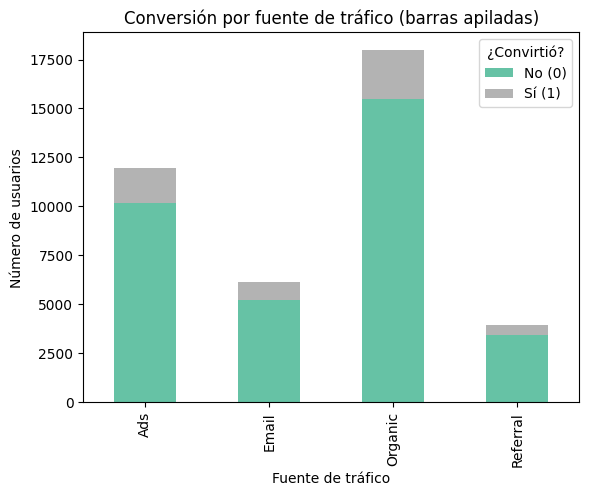

In [30]:
# Gráfica de barras apiladas: relación entre traffic_source y conversión

tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])

plt.figure(figsize=(8,5))
tabla_traffic.plot(kind='bar', stacked=True,  colormap='Set2')
plt.title("Conversión por fuente de tráfico (barras apiladas)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Cantidades absolutas
Las barras muestran que la cantidad de usuarios convertidos es muy baja en todas las fuentes de tráfico. No se observa un canal que destaque claramente en volumen de conversiones.**

<Figure size 800x500 with 0 Axes>

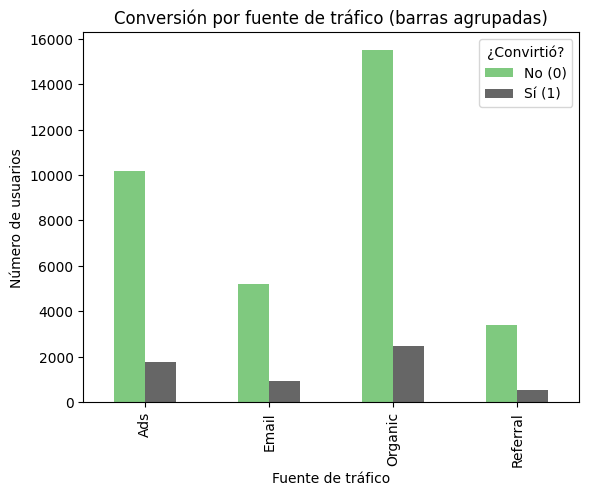

In [31]:
# Gráfica de barras agrupadas: relación entre traffic_source y conversión

tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])
plt.figure(figsize=(8,5))

tabla_traffic.plot(kind='bar', stacked=False, colormap='Accent')
plt.title("Conversión por fuente de tráfico (barras agrupadas)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Proporciones
Las proporciones de conversión entre Email, Ads y Organic son prácticamente idénticas. Esto coincide con el resultado de la prueba Chi‑cuadrado (p = 0.993), indicando que la fuente de tráfico no influye en la probabilidad de conversión.**


### Relación entre el tipo de usuario y la conversión

<Figure size 800x500 with 0 Axes>

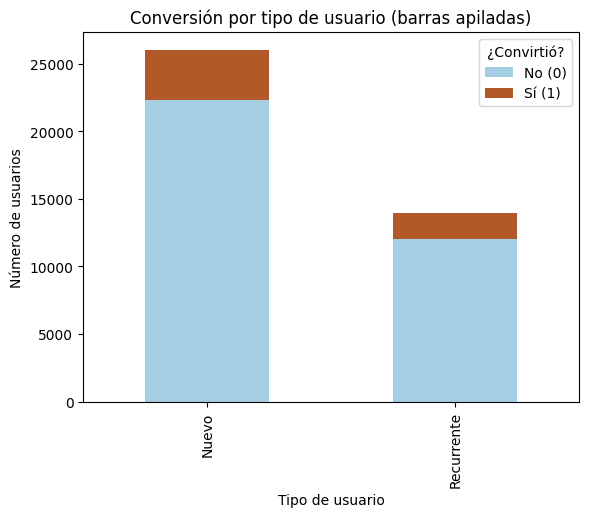

In [33]:
# Barras apiladas: tipo de usuario vs conversión

tabla_user = pd.crosstab(df['user_type'], df['converted'])

plt.figure(figsize=(8,5))
tabla_user.plot(kind='bar', stacked=True, colormap='Paired')
plt.title("Conversión por tipo de usuario (barras apiladas)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Cantidades absolutas
La gráfica muestra cuántos usuarios nuevos y recurrentes convirtieron y no convirtieron.
Se observa que la mayoría de usuarios, independientemente del tipo, no convierten, y el número de conversiones es bajo en ambos grupos.**

<Figure size 800x500 with 0 Axes>

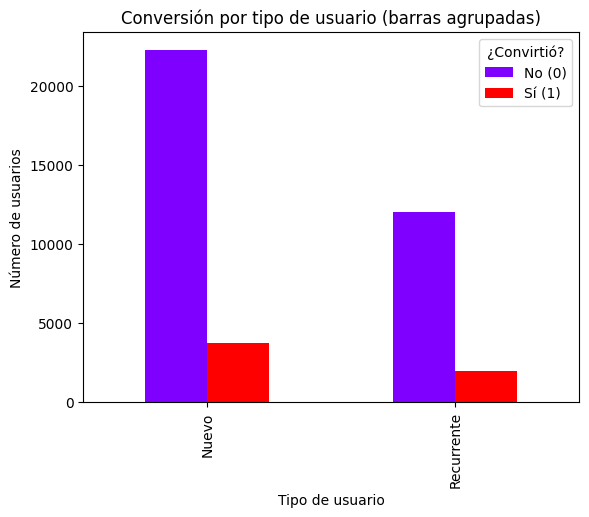

In [35]:
# Barras agrupadas: tipo de usuario vs conversión

plt.figure(figsize=(8,5))
tabla_user.plot(kind='bar', stacked=False, colormap='rainbow')
plt.title("Conversión por tipo de usuario (barras agrupadas)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

**Proporciones
Las proporciones de conversión entre usuarios nuevos y recurrentes son muy similares.
No se aprecia una diferencia visual clara que indique que un tipo de usuario convierta más que el otro.**

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- Observación 1: El gasto promedio entre A y B muestra una diferencia estadísticamente significativa (p ≈ 1e‑20).
- 
- Observación 2: Una de las páginas genera un gasto promedio claramente mayor.
- 
- **Interpretación:**
- La landing page influye directamente en el valor económico de los usuarios que convierten.
- 

**Tasa de conversión:** 
- Observación 1: La prueba Z de proporciones indica diferencias significativas entre A y B (p ≈ 3.7e‑22).
- Observación 2: Una de las páginas convierte a un porcentaje mucho mayor.
- **Interpretación:**

---La landing page es un factor determinante para la variable objetivo converted. La página ganadora debe priorizarse.

#### 📊 **Segmentación por fuente de tráfico**

- Observación: Las proporciones de conversión entre Email, Ads y Organic son prácticamente iguales. La prueba Chi‑cuadrado confirma que no hay relación (p = 0.993).
- 
- **Interpretación:**
- 
La fuente de tráfico no afecta la probabilidad de conversión. Las diferencias en volumen se deben al tamaño del tráfico, no a su efectividad.

#### 📊 **Segmentación por tipo de usuario**
- Observación: Usuarios nuevos y recurrentes presentan tasas de conversión muy similares. La prueba Chi‑cuadrado no muestra diferencias significativas.
- 
- **Interpretación:**

---El tipo de usuario no influye en la variable objetivo converted. 

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Priorizar la landing page ganadora
La página que mostró mayor tasa de conversión debe implementarse como versión principal. Es el factor con mayor impacto directo sobre converted, por lo que concentrar el tráfico en esta versión maximiza el número total de usuarios que convierten.

Redirigir mayor tráfico hacia la página más efectiva
Dado que la landing page es el principal driver de conversión, aumentar el volumen de usuarios que llegan a la página ganadora —especialmente desde campañas pagadas— incrementará de forma inmediata la cantidad total de conversiones.